FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

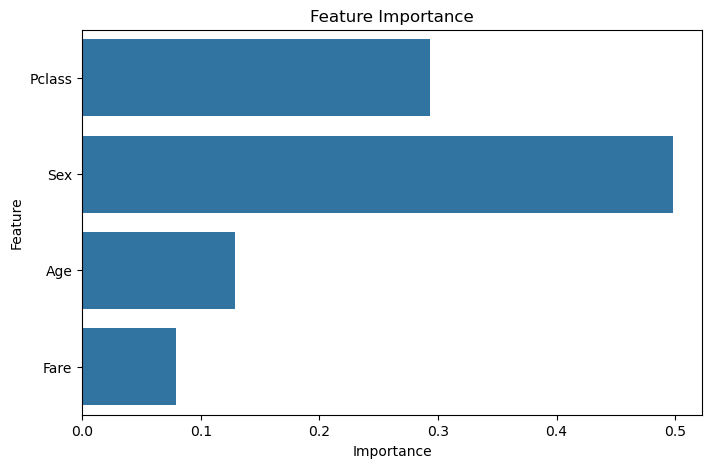

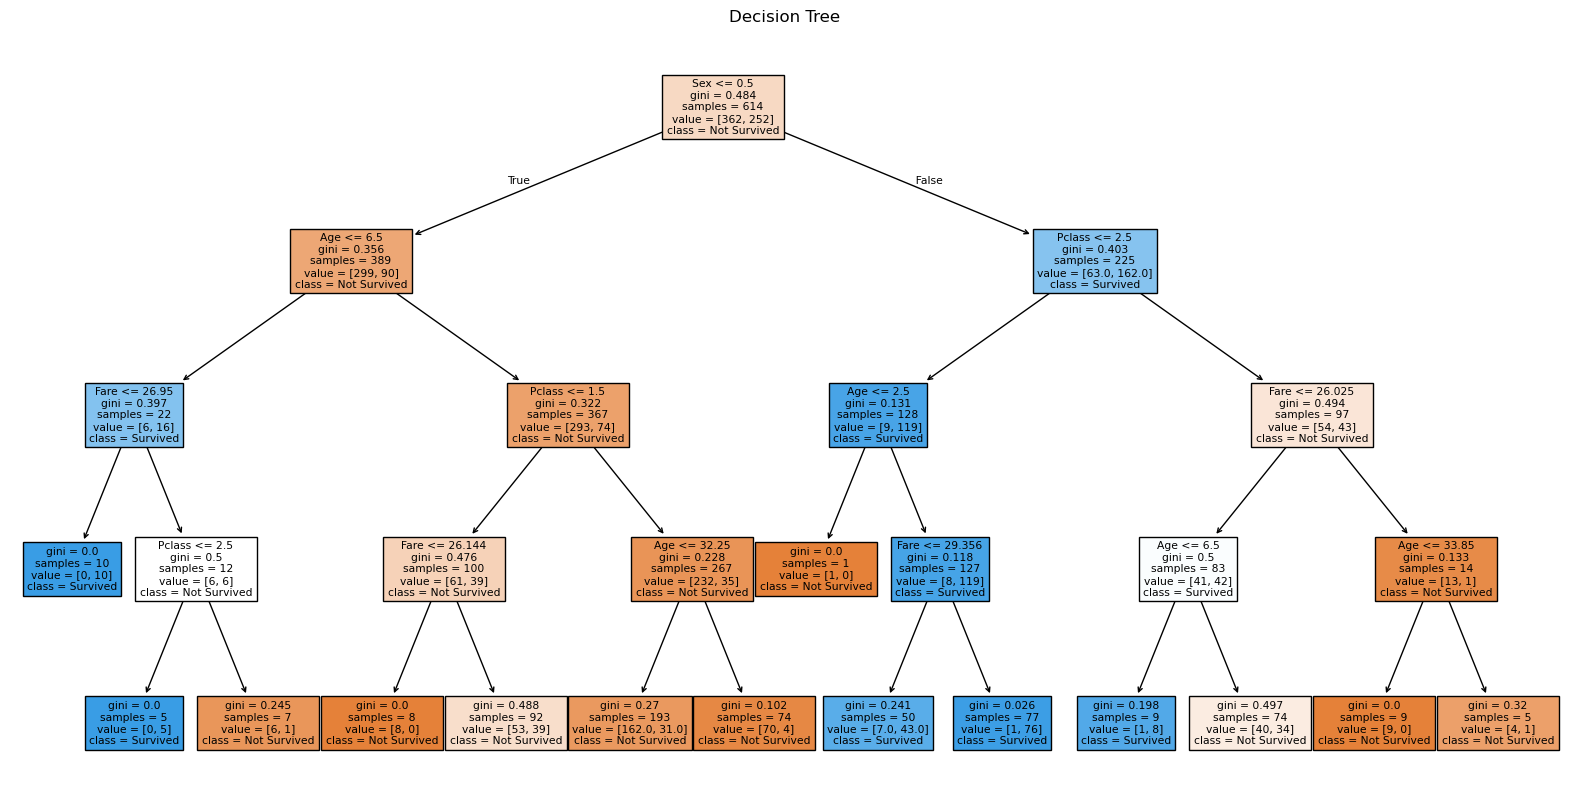


NEW PASSENGER PREDICTION
Passenger Survived


In [1]:
# ==========================================
# DECISION TREE CLASSIFICATION
# TITANIC SURVIVAL PREDICTION
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/decision_tree",
    exist_ok=True
)

os.makedirs(
    "../../../datasets/processed/decision_tree",
    exist_ok=True
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/titanic/train.csv"
)

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

# Select important columns

df = df[[
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Survived"
]]

# Handle missing values

df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

# Convert categorical values

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

# Remove duplicates

df = df.drop_duplicates()

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/decision_tree/cleaned_train.csv",
    index=False
)

print("\nCLEANED DATASET SAVED")

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df[[
    "Pclass",
    "Sex",
    "Age",
    "Fare"
]]

y = df["Survived"]

# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 6. SAVE PROCESSED DATASETS
# ==========================================

X_train.to_csv(
    "../../../datasets/processed/decision_tree/X_train.csv",
    index=False
)

X_test.to_csv(
    "../../../datasets/processed/decision_tree/X_test.csv",
    index=False
)

print("\nPROCESSED DATA SAVED")

# ==========================================
# 7. CREATE MODEL
# ==========================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# ==========================================
# 8. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED SUCCESSFULLY")

# ==========================================
# 9. PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

print("\nPREDICTIONS")
print(predictions[:10])

# ==========================================
# 10. EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nACCURACY")
print(accuracy)

print("\nCONFUSION MATRIX")
print(confusion_matrix(
    y_test,
    predictions
))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    predictions
))

# ==========================================
# 11. SAVE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv(
    "../../../datasets/processed/decision_tree/predictions.csv",
    index=False
)

print("\nPREDICTIONS SAVED")

# ==========================================
# 12. FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print("\nFEATURE IMPORTANCE")
print(importance)

# ==========================================
# 13. FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# ==========================================
# 14. DECISION TREE VISUALIZATION
# ==========================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)

plt.title("Decision Tree")

plt.show()

# ==========================================
# 15. PREDICT NEW PASSENGER
# ==========================================

new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": [1],
    "Age": [25],
    "Fare": [100]
})

prediction = model.predict(
    new_passenger
)

print("\nNEW PASSENGER PREDICTION")

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

# ==========================================
# END
# ==========================================